## Modelling voor klachten train set
### Notebook Modelling klachten classificatie voor correcte expertise

### Inhoud

1. [Inleiding](#modelling-voor-klachten-train-set)
2. [Preprocessing](#preprocessing)
3. [Modellen](#modellen)
    - [Logistic Regression](#logistic-regression)
    - [Naive Bayes](#naive-bayes)
    - [Random Forest](#random-forest)
    - [SVC](#svc)
    - [SVC Calibrated Linear](#svc-calibrated-linear)
    - [SVC Calibrated Logistic](#svc-calibrated-logistic)
    - [Confusion Matrix](#confusion-matrix)

In [83]:
# Imports libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import uniform, randint
from imblearn.pipeline import Pipeline
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.svm import LinearSVC
from scipy.sparse import hstack
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.validation import check_is_fitted
from scipy.sparse import issparse
from sklearn.exceptions import NotFittedError



In [84]:
# Natural language ToolKit downloads
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\casde\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Preprocessing

In [85]:
# Preprocessing met Tokenizer, Lemmitizer en Stopwords
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

train = pd.read_csv("klacht_train.csv")
test = pd.read_csv("klacht_test.csv")

train['Omschrijving_Cleaned'] = train['Omschrijving'].apply(preprocess_text)
test['Omschrijving_Cleaned'] = test['Omschrijving'].apply(preprocess_text)

y_train = train['Product']
y_test = test['Product']
x_train = train['Omschrijving_Cleaned']
x_test = test['Omschrijving_Cleaned']

In [86]:
# Print lengte train en test datasets
print(len(train))
print(len(test))

9527
2382


### Modellen

#### Gridsearch

In [87]:
# Gridsearch best estimator Pipeline
def run_search(pipeline, parameter_grid, name):
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        cv=5,
        scoring='precision_macro',
        n_jobs=6,
        verbose=2
    )

    grid_search.fit(train['Omschrijving_Cleaned'], y_train)

    print(f"GridSearch {name} - beste parameters:")
    print(grid_search.best_params_)

    print("\nClassification report:")
    print(classification_report(
        y_test,
        grid_search.predict(test['Omschrijving_Cleaned'])
    ))

    return grid_search.best_estimator_

#### Logistic regression

In [88]:
#logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=5000, solver='lbfgs')) #(clf is classifier)
])

# Parameters
lr_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [3000, 6000, 9000, 12000],
    'clf__C': [0.1, 1, 5, 10],
    'clf__penalty': ['l2'],
    'clf__class_weight': [None, 'balanced']
}

# Best Parameters en run search
lr_best = run_search(lr_pipeline, lr_parameters, "Logistic Regression")

Fitting 5 folds for each of 128 candidates, totalling 640 fits
GridSearch Logistic Regression - beste parameters:
{'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'vect': TfidfVectorizer(), 'vect__max_features': 6000, 'vect__ngram_range': (1, 2)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.86      0.84      0.85       240
Consumentenkrediet       0.88      0.54      0.67       156
        Creditcard       0.82      0.79      0.81       299
         Hypotheek       0.92      0.94      0.93       567
           Incasso       0.82      0.90      0.86       616
Kredietregistratie       0.84      0.85      0.84       504

          accuracy                           0.85      2382
         macro avg       0.86      0.81      0.83      2382
      weighted avg       0.86      0.85      0.85      2382



#### Naive Bayes

In [89]:
# Naive Bayes
nb_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

# Parameters
nb_parameters = {
    'vect': [TfidfVectorizer(), CountVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [3000, 6000, 9000, 12000],
    'clf__alpha': [0.1, 0.5, 1.0]
}

# Best Parameters en run search
nb_best = run_search(nb_pipeline, nb_parameters, "Naive Bayes")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearch Naive Bayes - beste parameters:
{'clf__alpha': 0.5, 'vect': TfidfVectorizer(), 'vect__max_features': 9000, 'vect__ngram_range': (1, 2)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.88      0.80      0.84       240
Consumentenkrediet       0.92      0.31      0.47       156
        Creditcard       0.82      0.73      0.77       299
         Hypotheek       0.84      0.95      0.89       567
           Incasso       0.82      0.88      0.85       616
Kredietregistratie       0.79      0.85      0.82       504

          accuracy                           0.82      2382
         macro avg       0.84      0.75      0.77      2382
      weighted avg       0.83      0.82      0.82      2382



#### Random Forest

In [90]:
# Random Forest
rf_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', RandomForestClassifier(random_state=42))
])

# Parameters
rf_parameters = {
    'vect': [TfidfVectorizer()],
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [5000, 10000],
    'clf__n_estimators': [200, 400],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

# Best Parameters en run search
rf_best = run_search(rf_pipeline, rf_parameters, "Random Forest")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
GridSearch Random Forest - beste parameters:
{'clf__class_weight': None, 'clf__max_depth': 20, 'clf__min_samples_split': 10, 'clf__n_estimators': 400, 'vect': TfidfVectorizer(), 'vect__max_features': 10000, 'vect__ngram_range': (1, 1)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.93      0.70      0.80       240
Consumentenkrediet       1.00      0.08      0.15       156
        Creditcard       0.90      0.58      0.70       299
         Hypotheek       0.82      0.93      0.87       567
           Incasso       0.69      0.92      0.78       616
Kredietregistratie       0.78      0.82      0.80       504

          accuracy                           0.78      2382
         macro avg       0.85      0.67      0.69      2382
      weighted avg       0.81      0.78      0.76      2382



### SVC

In [91]:
# Balanceerd classes met weinig of veel waarden
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw_dict = {cls: w for cls, w in zip(classes, cw)}

In [92]:
# LinearSVC
svc_pipeline = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', LinearSVC(class_weight=cw_dict))
])
# Parameters
svc_parameters = {
    'vect__ngram_range': [(1,1), (1,2)],
    'vect__max_features': [5000, 10000],
    'clf__C': [0.1, 1.0, 5.0, 10.0],
    'clf__max_iter': [2000, 5000, 10000],
    'clf__penalty': ['l2']
}
# Best parameters en run search
svc_best = run_search(svc_pipeline, svc_parameters, "LinearSVC")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GridSearch LinearSVC - beste parameters:
{'clf__C': 0.1, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'vect__max_features': 10000, 'vect__ngram_range': (1, 2)}

Classification report:
                    precision    recall  f1-score   support

      Bankrekening       0.82      0.87      0.84       240
Consumentenkrediet       0.81      0.70      0.75       156
        Creditcard       0.82      0.81      0.81       299
         Hypotheek       0.92      0.93      0.93       567
           Incasso       0.86      0.88      0.87       616
Kredietregistratie       0.86      0.84      0.85       504

          accuracy                           0.86      2382
         macro avg       0.85      0.84      0.84      2382
      weighted avg       0.86      0.86      0.86      2382



#### Confusion Matrixes

In [93]:
# Groepering modellen
modellen = {
    "Logistic Regression": lr_best,
    "Naive Bayes": nb_best,
    "Random Forest": rf_best,
    "LinearSVC": svc_best
}

In [94]:
# Benaming modellen
for name, model in modellen.items():
    print(name, type(model))

Logistic Regression <class 'imblearn.pipeline.Pipeline'>
Naive Bayes <class 'imblearn.pipeline.Pipeline'>
Random Forest <class 'imblearn.pipeline.Pipeline'>
LinearSVC <class 'imblearn.pipeline.Pipeline'>


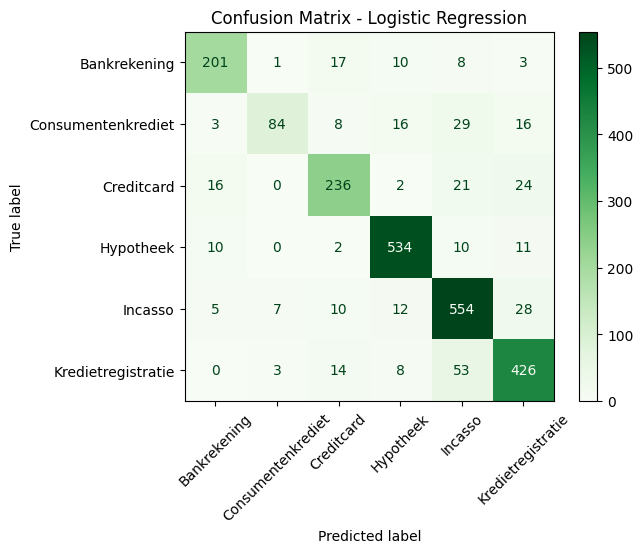

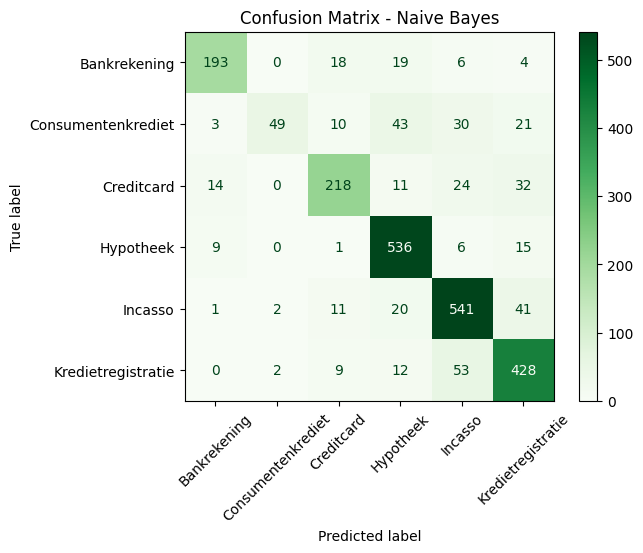

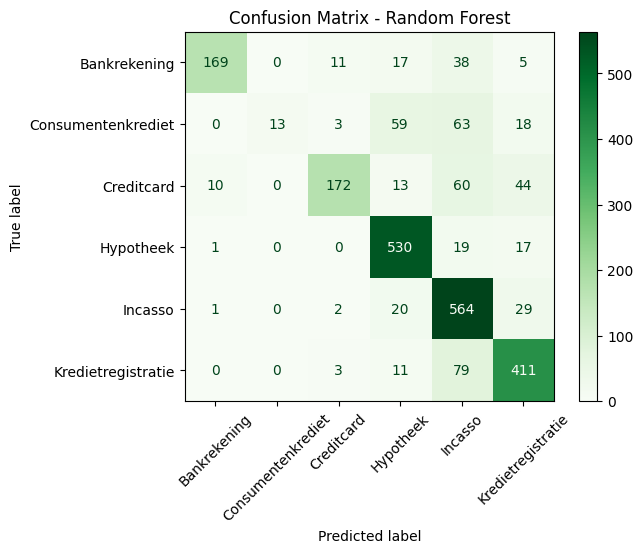

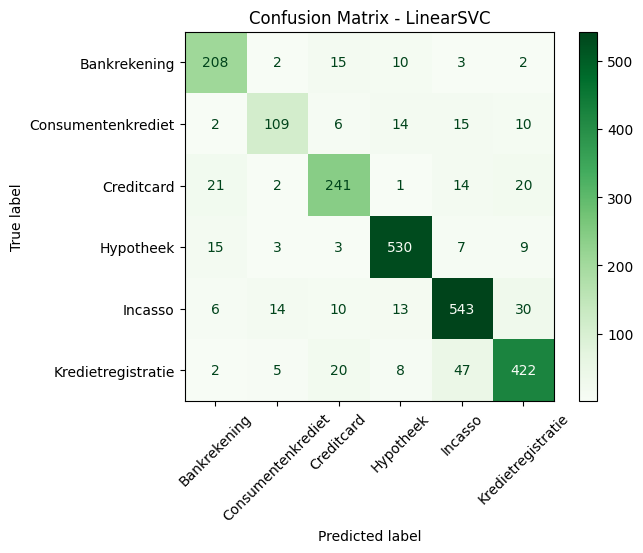

In [95]:
#Confusion matrixes alle 4 modellen
for name, model in modellen.items():
    y_pred = model.predict(x_test)
    confusion = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    display.plot(cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
#LinearSVC beste model, hoogste accuracy.